In [31]:
import os
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [32]:
# -------------------------------
# 1) GLOBAL PARAMS (tune here)
# -------------------------------
DATASET_PATH = "/kaggle/input/fyp-350-dataset-4/FYP 350 new 3"  # folder with class subfolders of .wav files
SAMPLE_RATE   = 16000
OFFSET_SEC    = 0           # start at 2s
DURATION_SEC  = 4.0           # take 5s (so 2s → 7s)
N_MELS        = 256
HOP_LENGTH    = 512
FMIN          = 20
FMAX          = SAMPLE_RATE // 2
TOP_DB        = 80            # dynamic range clamp in dB
TARGET_SIZE   = (256, 256)    # image size for MobileNet
BATCH_SIZE    = 32
EPOCHS        = 50
SEED          = 42
AUGMENT       = True          # image-level augmentation

In [33]:
# -------------------------------
# 2) AUDIO → MEL IMAGE
# -------------------------------
def audio_to_mel_image(path,
                       sample_rate=SAMPLE_RATE,
                       offset=OFFSET_SEC,
                       duration=DURATION_SEC,
                       n_mels=N_MELS,
                       hop_length=HOP_LENGTH,
                       fmin=FMIN,
                       fmax=FMAX,
                       top_db=TOP_DB,
                       target_size=TARGET_SIZE):
    # Load a fixed segment
    y, sr = librosa.load(path, sr=sample_rate, mono=True, offset=offset, duration=duration)

    # If shorter than desired segment, pad with zeros (rare but safe)
    needed = int(duration * sample_rate)
    if len(y) < needed:
        pad = needed - len(y)
        y = np.pad(y, (0, pad), mode='constant')

    # Mel spectrogram (power)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        hop_length=hop_length, fmin=fmin, fmax=fmax
    )
    # dB scaling with top_db clamp
    mel_db = librosa.power_to_db(mel, ref=np.max, top_db=top_db)  # shape: [n_mels, T]
    
    # Normalize to 0-1
    mel_min, mel_max = mel_db.min(), mel_db.max()
    mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)   # avoid div-by-zero

    # Resize to target size using TF (keeps everything in one stack)
    mel_tensor = tf.convert_to_tensor(mel_norm, dtype=tf.float32)         # [n_mels, T]
    mel_tensor = mel_tensor[tf.newaxis, ..., tf.newaxis]                  # [1, H, W, 1]
    mel_resized = tf.image.resize(mel_tensor, target_size, method='bilinear')  # [1, H, W, 1]

    # Repeat channels to 3 for ImageNet models
    mel_rgb = tf.repeat(mel_resized, repeats=3, axis=-1)  # [1, H, W, 3]
    return mel_rgb[0].numpy().astype(np.float32)          # [H, W, 3]


In [34]:
# -------------------------------
# 3) LOAD DATASET
# -------------------------------
def load_dataset(dataset_path):
    class_names = sorted([d for d in os.listdir(dataset_path)
                          if os.path.isdir(os.path.join(dataset_path, d))])
    X, y = [], []
    for idx, cname in enumerate(class_names):
        folder = os.path.join(dataset_path, cname)
        for fname in os.listdir(folder):
            if fname.lower().endswith(".wav"):
                fpath = os.path.join(folder, fname)
                img = audio_to_mel_image(fpath)
                X.append(img)
                y.append(idx)
    X = np.stack(X)  # [N, H, W, 3]
    y = np.array(y, dtype=np.int32)
    return X, y, class_names

print("Loading dataset (building Mel-spectrogram images)...")
X, y, class_names = load_dataset(DATASET_PATH)
num_classes = len(class_names)
print(f"Data: {X.shape}, Classes: {num_classes}, Names: {class_names}")

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Loading dataset (building Mel-spectrogram images)...
Data: (3150, 256, 256, 3), Classes: 9, Names: ['Burping', 'Laugh', 'Silence', 'Tired', 'awake', 'belly pain', 'discomfort', 'hug', 'hungry']
Train: (2205, 256, 256, 3), Val: (472, 256, 256, 3), Test: (473, 256, 256, 3)


In [35]:
# 4) TF DATA PIPELINES + AUGMENTATION
# -------------------------------
AUTOTUNE = tf.data.AUTOTUNE

def spec_augment(image):
    # image: [H, W, 3], H=mels, W=time
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    # small random time shift (±10% width)
    max_shift = tf.cast(0.1 * tf.cast(w, tf.float32), tf.int32)
    shift = tf.random.uniform([], -max_shift, max_shift + 1, dtype=tf.int32)
    image = tf.roll(image, shift=shift, axis=1)

    # frequency mask (up to 15% of mel bins)
    f = tf.random.uniform([], 0, tf.cast(0.15 * tf.cast(h, tf.float32), tf.int32) + 1, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, h - f + 1, dtype=tf.int32)
    freq_mask = tf.concat([
        tf.ones((f0, w, 3)),
        tf.zeros((f,  w, 3)),
        tf.ones((h - f0 - f, w, 3))
    ], axis=0)
    image = image * freq_mask

    # time mask (up to 15% of frames)
    t = tf.random.uniform([], 0, tf.cast(0.15 * tf.cast(w, tf.float32), tf.int32) + 1, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, w - t + 1, dtype=tf.int32)
    time_mask = tf.concat([
        tf.ones((h, t0, 3)),
        tf.zeros((h, t,  3)),
        tf.ones((h, w - t0 - t, 3))
    ], axis=1)
    image = image * time_mask
    return image

def aug_fn(image, label):
    if AUGMENT:
        image = spec_augment(image)
        # keep size consistent (already 224x224 from your mel builder)
        image = tf.image.resize_with_crop_or_pad(image, TARGET_SIZE[0], TARGET_SIZE[1])
    return image, label

In [36]:
def to_model_space(image, label):
    # your mel images are in [0,1]; mobilenet_v2.preprocess_input expects [0,255]
    image = preprocess_input(image * 255.0)
    return image, label
    
def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.map(to_model_space, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val, y_val, training=False)
test_ds  = make_ds(X_test, y_test, training=False)

In [37]:
# New additions
# -------------------------------
# 5) MODEL: MobileNetV2 backbone
# -------------------------------
# MobileNetV2 expects inputs in [0,1] if not using preprocess_input; we’re already in 0–1.
backbone = MobileNetV2(
    input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
backbone.trainable = False  # start with frozen backbone; unfreeze later for fine-tuning

inputs = layers.Input(shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3))
x = backbone(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512,activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax',kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)


model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/tmp/ipykernel_36/1951638362.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,086,921 (11.78 MB)

 Trainable params: 828,937 (3.16 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

# then:
#history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=cb, class_weight=class_weight)
# and again for fine-tune


In [39]:
# -------------------------------
# 7) OPTIONAL: Fine-tune backbone
# -------------------------------
# Unfreeze from some depth and continue with a low LR if val plateaus.
UNFREEZE = True
if UNFREEZE:
    # Unfreeze last N blocks (here: last 40% of layers)
    for i, layer in enumerate(backbone.layers[int(len(backbone.layers)*0.1):]):
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # low LR for fine-tune
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    ft_callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
        ModelCheckpoint("mobilenet_mel_finetuned.h5", monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=ft_callbacks,
        class_weight=class_weight,
        verbose=1
    )

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.1361 - loss: 2.3845
Epoch 1: val_accuracy improved from -inf to 0.15254, saving model to mobilenet_mel_finetuned.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 83s 440ms/step - accuracy: 0.1363 - loss: 2.3830 - val_accuracy: 0.1525 - val_loss: 2.1721 - learning_rate: 1.0000e-04
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1970 - loss: 2.1127
Epoch 2: val_accuracy improved from 0.15254 to 0.27119, saving model to mobilenet_mel_finetuned.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.1971 - loss: 2.1122 - val_accuracy: 0.2712 - val_loss: 2.0639 - learning_rate: 1.0000e-04
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2779 - loss: 1.9352
Epoch 3: val_accuracy improved from 0.27119 to 0.34958, saving model to mobilenet_mel_finetuned.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.2780 - loss: 1.9349 - val_accuracy: 0.3496 - val_loss: 1.8526 - learning_rate: 1.0000e-04
Epoch 4/50
6


Evaluating on test set...
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step
Test Accuracy: 88.79%

Classification Report:
              precision    recall  f1-score   support

     Burping     0.9804    0.9615    0.9709        52
       Laugh     0.9123    1.0000    0.9541        52
     Silence     0.9623    0.9623    0.9623        53
       Tired     1.0000    0.9811    0.9905        53
       awake     0.8704    0.8868    0.8785        53
  belly pain     0.8140    0.6731    0.7368        52
  discomfort     0.7193    0.7736    0.7455        53
         hug     0.8824    0.8654    0.8738        52
      hungry     0.8545    0.8868    0.8704        53

    accuracy                         0.8879       473
   macro avg     0.8884    0.8878    0.8870       473
weighted avg     0.8883    0.8879    0.8870       473



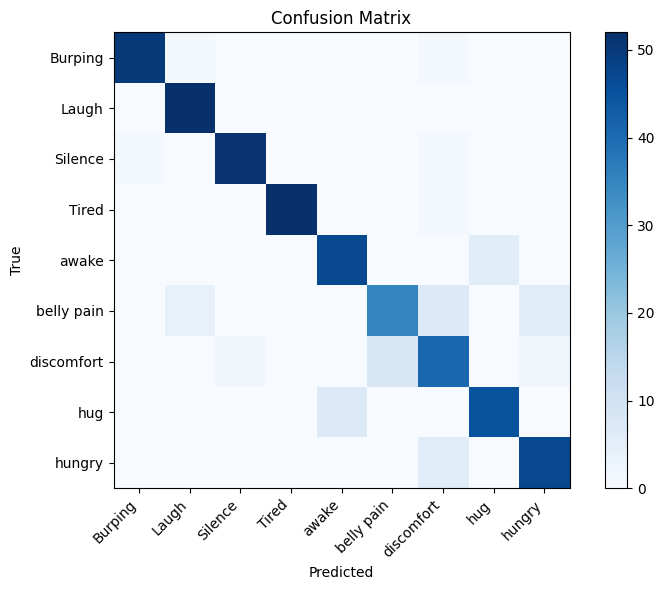

In [40]:
# -------------------------------
# 8) EVALUATE + REPORTS
# -------------------------------
print("\nEvaluating on test set...")
test_probs = model.predict(test_ds)
y_pred = np.argmax(test_probs, axis=1)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(num_classes), class_names, rotation=45, ha='right')
plt.yticks(np.arange(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [42]:
# -------------------------------
# 9) SAVE / LOAD
# -------------------------------
model.save("mobilenet_mel_final2.keras")  
model.save("mobilenet_good.h5")# SavedModel/Keras v3 format
# To load later:
# loaded = tf.keras.models.load_model("mobilenet_mel_final.keras")

# from tensorflow.keras.models import load_model

# model = load_model("mobilenet_mel_final.keras")
# pred_class, conf, all_probs = predict_file(
#     "/path/to/one.wav",
#     model,
#     class_names  # you need the same class_names list you had during training
# )


In [ ]:
def predict_file(path, model, class_names):
    img = audio_to_mel_image(path)                 # [H,W,3], 0–1
    img = np.expand_dims(img, 0)                   # [1,H,W,3]
    probs = model.predict(img)[0]
    idx = int(np.argmax(probs))
    return class_names[idx], float(probs[idx]), probs

In [ ]:
# Example:
pred_class, conf, all_probs = predict_file("/kaggle/input/fyp-350-dataset2/FYP 350 Dataset/burping/466c.wav", model, class_names)
print(f"Predicted: {pred_class} ({conf*100:.2f}%)")